In [ ]:
import vertexai

PROJECT_ID = "spring-2026-lifejacket"
REGION = "us-central1"
vertexai.init(project=PROJECT_ID, location=REGION)

In [ ]:
from PIL import Image as PILImage
from PIL import ImageEnhance, ImageFilter
import random

In [ ]:
DISTORTION_CONFIGS = {
    0: {
        "brightness": (1.0, 1.0),
        "contrast": (1.0, 1.0),
        "color": (1.0, 1.0),
        "sharpness": (1.0, 1.0),
        "rotate": False
    },

    1: {
        "brightness": (0.80, 1.20),
        "contrast": (0.85, 1.15),
        "color": (0.75, 1.25),
        "sharpness": (0.70, 1.30),
        "rotate": False
    },

    2: {
        "brightness": (0.60, 0.79),
        "contrast": (0.65, 0.84),
        "color": (0.50, 0.74),
        "sharpness": (0.20, 0.50),
        "rotate": False
    },

    3: {
        "brightness": (0.40, 0.59),
        "contrast": (0.35, 0.64),
        "color": (0.15, 0.49),
        "sharpness": (0.01, 0.15),
        "rotate": True
    },

    4: {
        "brightness": (0.20, 0.39),
        "contrast": (0.20, 0.34),
        "color": (0.01, 0.14),
        "sharpness": (0.0, 0.0),
        "rotate": True
    },

    5: {
        "brightness": (0.45, 0.55),
        "contrast": (0.05, 0.12),
        "color": (0.0, 0.0),
        "sharpness": (0.0, 0.0),
        "rotate": True
    }
}

In [ ]:
def apply_distortion(image_path, distortion_level, output_folder="distorted_test_images"):
    os.makedirs(output_folder, exist_ok=True)

    config = DISTORTION_CONFIGS[distortion_level]

    img = PILImage.open(image_path).convert("RGB")

    # brightness
    brightness_factor = random.uniform(*config["brightness"])
    img = ImageEnhance.Brightness(img).enhance(brightness_factor)

    # contrast
    contrast_factor = random.uniform(*config["contrast"])
    img = ImageEnhance.Contrast(img).enhance(contrast_factor)

    # color
    color_factor = random.uniform(*config["color"])
    img = ImageEnhance.Color(img).enhance(color_factor)

    # sharpness
    sharpness_factor = random.uniform(*config["sharpness"])
    img = ImageEnhance.Sharpness(img).enhance(sharpness_factor)

    # additional blur for severe distortion
    if distortion_level >= 2:
        blur_radius = distortion_level * 0.8
        img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # rotate if needed
    if config["rotate"]:
        angle = random.choice([90, 180, 270])
        img = img.rotate(angle, expand=True)

    base_name = os.path.splitext(os.path.basename(image_path))[0]
    output_path = os.path.join(
        output_folder,
        f"{base_name}_distortion_level_{distortion_level}.jpg"
    )

    img.save(output_path, quality=90)

    return output_path

In [ ]:
import vertexai
import pandas as pd
import os
import mimetypes
import json
import re

from IPython.display import Image, display
from vertexai.generative_models import (
    GenerativeModel,
    Part,
    ChatSession,
    HarmCategory,
    HarmBlockThreshold
)

In [ ]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 8192,
}

cv_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

llm_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

In [ ]:
# real CV input by image filename

import os
from IPython.display import Image, display

IMAGE_FOLDER = "../Gemini Confidence Testing/hurt_animal_dataset_images"

TARGET_IMAGE_FILENAME = "309081568.jpg"

image_path = os.path.join(IMAGE_FOLDER, TARGET_IMAGE_FILENAME)

if not os.path.exists(image_path):
    print("Image not found:", image_path)

    image_files = [
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    print("Number of images found:", len(image_files))
    print("First 20 images:", image_files[:20])

    matches = [f for f in image_files if "309081568" in f]
    print("Possible matches:", matches)

else:
    image_filename = TARGET_IMAGE_FILENAME

    print("Selected image:", image_filename)
    print("Image path:", image_path)

    display(Image(filename=image_path, width=350))

In [ ]:
original_image_path = image_path
original_image_filename = image_filename

print("Original image path saved:", original_image_path)

In [ ]:
DISTORTION_LEVEL = 2

distorted_image_path = apply_distortion(
    image_path=image_path,
    distortion_level=DISTORTION_LEVEL,
    output_folder="distorted_test_images"
)

print("Original image path:", image_path)
print("Distorted image path:", distorted_image_path)

print("\nOriginal image:")
display(Image(filename=image_path, width=300))

print("\nDistorted image:")
display(Image(filename=distorted_image_path, width=300))

In [ ]:
cv_image_path = distorted_image_path

print("CV will use this image:")
print(cv_image_path)

display(Image(filename=cv_image_path, width=350))

In [26]:
#mock location output
location_output = {
    "location_available": False,
    "location_source": "mock_location_for_testing",
    "latitude": None,
    "longitude": None,
    "place_name": "Unknown test location",
    "image_filename": image_filename,
    "image_date": "",
    "image_time": ""
}

print("Mock location output:")
print(json.dumps(location_output, indent=2))

Mock location output:
{
  "location_available": false,
  "location_source": "mock_location_for_testing",
  "latitude": null,
  "longitude": null,
  "place_name": "Unknown test location",
  "image_filename": "309081568.jpg",
  "image_date": "",
  "image_time": ""
}


In [27]:
def extract_json_from_response(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end <= start:
        print("Raw response:")
        print(text)
        raise ValueError("No complete JSON object found in Gemini response.")

    json_text = text[start:end + 1]

    try:
        return json.loads(json_text)
    except json.JSONDecodeError as e:
        print("JSON parsing failed:", e)
        print("Extracted JSON text:")
        print(json_text)
        raise

## CV prompt +CV module

In [28]:
def build_cv_prompt(location_output):
    metadata_context = json.dumps(location_output, indent=2)

    return f"""
You are an expert wildlife species identification model executing a CDRL calibration process for a wildlife rescue dispatch system.

Observation metadata:
{metadata_context}

Task:
- Analyze the provided animal image.
- Identify the top 2 likely species or animal groups based on the image and available metadata.
- Estimate calibrated probabilities as integers from 0 to 100.
- Detect whether the image is clear enough for species and injury assessment.
- Detect whether there may be a visible wound.
- Detect whether visible blood appears.
- Provide a Maximum Confidence Query: one safe, non-invasive question an observer can answer from a distance using visual cues only.

Rules:
- A high probability requires definitive, unambiguous visual traits.
- Be honest and avoid overconfidence.
- If critical diagnostic features are missing, scale down probability.
- If the image is dark, blurry, blocked, or the animal is only partially visible, set image_clear to false or lower probabilities.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- The Maximum Confidence Query must be safe and answerable from a distance.
- Do not ask the observer to approach, touch, feed, move, measure, or disturb the animal.
- Return valid JSON only.
- Do not include markdown.
- Keep all string values short.

Return JSON exactly in this schema:
{{
  "cv_species_top2": [
    {{
      "common_name": "",
      "genus": "",
      "species": "",
      "probability": 0
    }},
    {{
      "common_name": "",
      "genus": "",
      "species": "",
      "probability": 0
    }}
  ],
  "cv_observed_features": {{
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "",
    "gaps_and_limits": "",
    "maximum_confidence_query": ""
  }}
}}
"""


def generate_cv_output_from_image(model, image_path, location_output):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = build_cv_prompt(location_output)

    response = model.generate_content([prompt, image_part])
    cv_output = extract_json_from_response(response.text)

    return cv_output

cv_output = generate_cv_output_from_image(
    model=cv_model,
    image_path=image_path,
    location_output=location_output
)

print("CV output:")
print(json.dumps(cv_output, indent=2))

In [29]:
distorted_cv_output = generate_cv_output_from_image(
    model=cv_model,
    image_path=cv_image_path,
    location_output=location_output
)

print("Distorted CV output:")
print(json.dumps(distorted_cv_output, indent=2))

Distorted CV output:
{
  "cv_species_top2": [
    {
      "common_name": "Manatee",
      "genus": "Trichechus",
      "species": "",
      "probability": 10
    },
    {
      "common_name": "Sea Turtle",
      "genus": "",
      "species": "",
      "probability": 5
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": false,
    "image_clarity_reason": "Image is very dark, blurry, and lacks detail.",
    "gaps_and_limits": "The animal is largely submerged and indistinct. Critical diagnostic features are not visible for species identification or injury assessment.",
    "maximum_confidence_query": "Can you observe if the object is moving or if any other parts of it become visible?"
  }
}


## Pre Fix question

In [30]:
fixed_question_options = {
    "reported_size": {
        "question": "What is the animal's approximate body length?",
        "options": {
            "A": "very_small_under_1_ft",
            "B": "small_1_to_3_ft",
            "C": "medium_3_to_6_ft",
            "D": "large_6_to_10_ft",
            "E": "very_large_over_10_ft",
            "F": "not_sure"
        }
    },
    "reported_body_covering": {
        "question": "What does the animal's body covering look like?",
        "options": {
            "A": "fur_or_hair",
            "B": "feathers",
            "C": "scales_or_shell",
            "D": "smooth_skin",
            "E": "not_sure"
        }
    },
    "reported_mobility": {
        "question": "Is the animal moving?",
        "options": {
            "A": "moving_normally",
            "B": "moving_slowly_or_weakly",
            "C": "not_moving_but_appears_alive",
            "D": "not_moving_may_be_dead",
            "E": "not_sure"
        }
    },
    "reported_visible_wound": {
        "question": "Do you see any visible wound?",
        "options": {
            "A": True,
            "B": False,
            "C": "not_sure"
        }
    },
    "reported_extra_condition": {
        "question": "Please briefly describe anything else you notice about the animal's condition, such as bleeding, entanglement, breathing, posture, nearby people, or unusual behavior.",
        "free_response": True
    }
}

In [31]:
def ask_fixed_questions(fixed_question_options):
    user_fixed_answers = {}

    for key, item in fixed_question_options.items():
        print("\n" + item["question"])

        if item.get("free_response", False):
            answer = input("Your answer: ").strip()
            user_fixed_answers[key] = answer if answer else "not_provided"
            continue

        options = item["options"]

        for letter, value in options.items():
            print(f"{letter}: {value}")

        while True:
            choice = input("Choose one option: ").strip().upper()

            if choice in options:
                user_fixed_answers[key] = options[choice]
                break

            print("Invalid option. Please choose one of:", list(options.keys()))

    return user_fixed_answers


user_fixed_answers = ask_fixed_questions(fixed_question_options)

print("\nUser fixed answers:")
print(json.dumps(user_fixed_answers, indent=2))


What is the animal's approximate body length?
A: very_small_under_1_ft
B: small_1_to_3_ft
C: medium_3_to_6_ft
D: large_6_to_10_ft
E: very_large_over_10_ft
F: not_sure


Choose one option:  F



What does the animal's body covering look like?
A: fur_or_hair
B: feathers
C: scales_or_shell
D: smooth_skin
E: not_sure


Choose one option:  E



Is the animal moving?
A: moving_normally
B: moving_slowly_or_weakly
C: not_moving_but_appears_alive
D: not_moving_may_be_dead
E: not_sure


...


Do you see any visible wound?
A: True
B: False
C: not_sure


Choose one option:  B



Please briefly describe anything else you notice about the animal's condition, such as bleeding, entanglement, breathing, posture, nearby people, or unusual behavior.


Your answer:  



User fixed answers:
{
  "reported_size": "not_sure",
  "reported_body_covering": "not_sure",
  "reported_mobility": "not_sure",
  "reported_visible_wound": false,
  "reported_extra_condition": "not_provided"
}


## Incident Package

In [32]:
incident_package = {
    "cv_output": distorted_cv_output,
    "location_output": location_output,
    "user_fixed_answers": user_fixed_answers
}

print("Incident package:")
print(json.dumps(incident_package, indent=2))

Incident package:
{
  "cv_output": {
    "cv_species_top2": [
      {
        "common_name": "Manatee",
        "genus": "Trichechus",
        "species": "",
        "probability": 10
      },
      {
        "common_name": "Sea Turtle",
        "genus": "",
        "species": "",
        "probability": 5
      }
    ],
    "cv_observed_features": {
      "possible_wound": false,
      "visible_blood": false,
      "image_clear": false,
      "image_clarity_reason": "Image is very dark, blurry, and lacks detail.",
      "gaps_and_limits": "The animal is largely submerged and indistinct. Critical diagnostic features are not visible for species identification or injury assessment.",
      "maximum_confidence_query": "Can you observe if the object is moving or if any other parts of it become visible?"
    }
  },
  "location_output": {
    "location_available": false,
    "location_source": "mock_location_for_testing",
    "latitude": null,
    "longitude": null,
    "place_name": "Unknown

## LLM assessment prompt

In [33]:
def build_assessment_prompt(incident_package, followup_history=None):
    if followup_history is None:
        followup_history = []

    prompt = f"""
You are Agent 1: Wildlife Species Identification Expert.

You receive:
1. incident_package
2. followup_history

The incident_package contains:
- cv_output from a computer vision module
- location_output from a mocked location service
- user_fixed_answers from fixed intake questions

Your task:
- Combine cv_output, user_fixed_answers, location_output, and followup_history.
- Identify the most likely species-level candidate.
- Produce an updated species confidence score between 0 and 1.
- Use CV output as the main visual evidence.
- Use fixed user answers as reporter evidence.
- Use followup_history as additional reporter evidence.
- Do not simply copy the CV probability, but do not ignore a high CV probability without strong contradictory evidence.
- Summarize why the species confidence is high or low.
- Summarize injury or distress evidence.
- Suggest one useful follow-up question if more information would improve species identification.
- If species confidence is already high, suggested_followup_question can be an empty string.

Animal group rules:
- llm_likely_animal_group must be exactly one of "pinniped", "cetacean", "sea_turtle", "other", "unknown".
- pinniped: seals, sea lions, fur seals, elephant seals, walruses. cetacean: whales, dolphins, porpoises. sea_turtle: all sea turtles.
- Base it on the selected llm_likely_species when that species is plausible, otherwise on the strongest group-level evidence.
- Agent 2 routes dispatch by this group, so it can be confident even when the exact species is uncertain.

Species-level rules:
- The final llm_likely_species should be the most specific species-level candidate available.
- Prefer a species-level candidate from cv_species_top2 when available.
- Do not replace a high-probability CV species candidate with "unknown_species" only because the image is unclear.
- Use "unknown_species" only when CV provides no plausible species-level candidate or all evidence is contradictory.
- If CV top candidate has high probability, keep it as the leading candidate unless user answers strongly contradict it.
- llm_species_confidence must measure confidence in the selected species candidate.

Confidence calibration rules:
- Convert CV probability to a rough starting point, then adjust using user answers and followup_history.
- If user answers support the CV top species with species-distinguishing traits, increase or maintain confidence.
- If user answers conflict with the CV top species, lower confidence and ask a clarifying question.
- Do not increase species confidence based only on condition evidence such as movement, breathing, sound, injury, or distress.
- Use condition evidence to update injury_summary or safety_guidance, not species confidence, unless it directly helps distinguish the species.
- If followup_history resolves a previous species-identification conflict, update confidence upward.
- If followup_history creates a new species-identification conflict, update confidence downward.

Follow-up priority rules:
- The main confidence threshold is for species identification.
- If llm_species_confidence is below 0.90, first ask the most useful follow-up question for confirming or rejecting the current top species candidate from cv_species_top2.
- The follow-up question should target the most distinctive visual trait of the current top species, compared with similar species.
- Do not ask a generic animal question if a more species-specific trait question is available.
- Do not ask a generic animal question if a more species-specific trait question is available.- Do not ask a generic animal question if a more species-specific trait question is available.
- Do not ask broad questions already answered in user_fixed_answers.
- The fixed user answers already include general size, body covering, mobility, visible wound, and extra condition.
- Ask a more specific clarification question instead of repeating fixed questions.
- When asking about size or body shape, include a clear comparison or reference point.
- If the main uncertainty is between similar species, ask about distinguishing visual traits.
- If the main uncertainty is caused by a conflict between CV output and user answers, ask one question that resolves that conflict.
- Before the species is confirmed, do not prioritize condition questions such as movement, breathing, sound, injury, or distress unless there is an urgent safety concern.
- Ask an injury or condition follow-up only if it is more urgent than species identification.


Important rules:
- The CV module already analyzed the image.
- Do not ask a question already answered in user_fixed_answers.
- Do not ask a question already answered in followup_history.
- Ask only one thing in the suggested follow-up question.
- The follow-up question must be safe and answerable from a distance.
- Do not ask the user to approach, touch, feed, move, measure, or disturb the animal.
- Keep all string values short.
- Return valid JSON only.
- Do not include markdown.
- Do not include newline characters inside string values.
- Do not use trailing commas.

Injury and distress flag rules:
- These flags are passed to Agent 2 for severity triage. Report only what the evidence supports.
- Use JSON true or false for every flag. Never leave a flag empty.
- Set a flag to true only when cv_output, user_fixed_answers (including reported_extra_condition), or followup_history gives direct evidence for it.
- Set a flag to false when there is no evidence for it. Do not guess from species or location alone.
- llm_wound_present: visible wound, cut, bite, or lesion reported or seen.
- llm_bleeding_present: blood or active bleeding reported or seen.
- llm_entanglement_present: net, line, rope, plastic, or other material wrapped on the animal.
- llm_swelling_present: swelling, lumps, or bloating reported or seen.
- llm_abnormal_posture_present: unusual posture, such as head down, twisted body, or lying in an unusual position.
- llm_respiratory_distress_present: labored, rapid, noisy, or open-mouth breathing, or breathing difficulty.
- llm_unresponsive_present: animal does not react to nearby people or noise, or may be dead.
- llm_injury_present: true if any wound, bleeding, entanglement, swelling, abnormal posture, respiratory distress, or unresponsive flag is true.
- llm_injury_confidence: a number from 0 to 1 for how sure you are about llm_injury_present.
- llm_mobility_concern: exactly one of "none", "limited", "immobile", "unknown", based mainly on reported_mobility.
  moving_normally -> "none"; moving_slowly_or_weakly -> "limited"; not_moving_but_appears_alive or not_moving_may_be_dead -> "immobile"; not_sure -> "unknown".
- injury_summary must stay consistent with these flags.

cv_user_agreement_status rules:
- Output exactly one of these values:
  "agreement"
  "partial_agreement"
  "conflict"
  "insufficient_information"
- Do not explain this field.
- Put explanation only in confidence_evidence_summary.

JSON formatting rules:
- Return one complete valid JSON object.
- Use double quotes for all keys and string values.
- Every string value must be under 25 words.
- confidence_evidence_summary must be one short sentence.
- injury_summary must be one short sentence.
- safety_guidance must be one short sentence.
- suggested_followup_question must be one short question.

Input incident_package:
{json.dumps(incident_package, separators=(",", ":"))}

Follow-up history:
{json.dumps(followup_history, separators=(",", ":"))}

Return JSON exactly in this schema:
{{
  "llm_likely_species": "",
  "llm_likely_animal_group": "",
  "llm_species_confidence": 0.0,
  "confidence_evidence_summary": "",
  "cv_user_agreement_status": "",
  "suggested_followup_question": "",
  "injury_summary": "",
  "safety_guidance": "",
  "llm_injury_present": false,
  "llm_injury_confidence": 0.0,
  "llm_wound_present": false,
  "llm_bleeding_present": false,
  "llm_entanglement_present": false,
  "llm_swelling_present": false,
  "llm_abnormal_posture_present": false,
  "llm_respiratory_distress_present": false,
  "llm_unresponsive_present": false,
  "llm_mobility_concern": ""
}}
"""
    return prompt

## LLM assessment function

def assess_incident_with_llm(model, incident_package, followup_history=None):
    prompt = build_assessment_prompt(
        incident_package=incident_package,
        followup_history=followup_history
    )

    response = model.generate_content(prompt)
    llm_output = extract_json_from_response(response.text)

    return llm_output

In [34]:
def assess_incident_with_llm(model, incident_package, followup_history=None):
    prompt = build_assessment_prompt(
        incident_package=incident_package,
        followup_history=followup_history
    )

    response = model.generate_content(prompt)

    print("Raw response:")
    print(response.text)

    try:
        print("Finish reason:", response.candidates[0].finish_reason)
    except Exception as e:
        print("Could not read finish reason:", e)

    llm_output = extract_json_from_response(response.text)

    return llm_output

## Python control module

In [35]:
def decide_next_action(llm_output, incident_package, followup_history, max_followups=5):
    confidence = llm_output.get("llm_species_confidence", 0.0)
    question = llm_output.get("suggested_followup_question", "").strip()

    cv_features = (
        incident_package
        .get("cv_output", {})
        .get("cv_observed_features", {})
    )

    image_clear = cv_features.get("image_clear", True)

    # Case 1: high confidence, stop and output final result
    if confidence >= 0.90:
        return {
            "action": "stop_verified",
            "reason": "Updated confidence is at least 0.90.",
            "question": ""
        }

    # Case 2: very low confidence and bad image, ask for retake
    if confidence < 0.50 and image_clear is False:
        return {
            "action": "request_new_photo",
            "reason": "Updated confidence is below 0.50 and the image is not clear.",
            "question": "Please upload another photo from a safe distance if possible."
        }

    # Case 3: max follow-up limit reached
    if len(followup_history) >= max_followups:
        return {
            "action": "stop_uncertain",
            "reason": "Maximum follow-up limit reached.",
            "question": ""
        }

    # Case 4: no useful follow-up question
    if not question:
        return {
            "action": "stop_uncertain",
            "reason": "No useful follow-up question was generated.",
            "question": ""
        }

    # Case 5: avoid exact repeated questions
    asked_questions = [
        item.get("question", "").strip().lower()
        for item in followup_history
    ]

    if question.lower() in asked_questions:
        return {
            "action": "stop_uncertain",
            "reason": "The suggested follow-up question was already asked.",
            "question": ""
        }

    # Case 6: normal follow-up
    return {
        "action": "ask_followup",
        "reason": "Updated confidence is below 0.90, but image is usable.",
        "question": question
    }

## Chatbox Loop

In [36]:
def run_chatbox(model, incident_package, max_followups=5):
    followup_history = []

    while True:
        print("\nSending incident_package + followup_history to LLM assessment...")

        llm_output = assess_incident_with_llm(
            model=model,
            incident_package=incident_package,
            followup_history=followup_history
        )

        print("\nLLM assessment output:")
        print("Animal group:", llm_output.get("llm_likely_animal_group"))
        print("Likely species:", llm_output.get("llm_likely_species"))
        print("Updated confidence:", llm_output.get("llm_species_confidence"))
        print("CV-user agreement:", llm_output.get("cv_user_agreement_status"))
        print("Evidence summary:", llm_output.get("confidence_evidence_summary"))
        print("Injury summary:", llm_output.get("injury_summary"))
        print("Guidance:", llm_output.get("safety_guidance"))

        decision = decide_next_action(
            llm_output=llm_output,
            incident_package=incident_package,
            followup_history=followup_history,
            max_followups=max_followups
        )

        print("\nPython control decision:")
        print("Action:", decision["action"])
        print("Reason:", decision["reason"])

        if decision["action"] == "stop_verified":
            print("\nFinal result: verified with high confidence.")
            return llm_output, followup_history

        if decision["action"] == "request_new_photo":
            print("\nRetake request:")
            print(decision["question"])

            new_image_path = input("New image path, or press Enter to stop: ").strip()

            if not new_image_path:
                print("No new image submitted. Stop and save current uncertain result.")
                return llm_output, followup_history

            print("\nDisplaying new image:")
            display(Image(filename=new_image_path, width=350))

            print("\nGenerating new CV output from retaken image...")

            new_cv_output = generate_cv_output_from_image(
                model=cv_model,
                image_path=new_image_path,
                location_output=incident_package.get("location_output", {})
            )

            incident_package["cv_output"] = new_cv_output

            followup_history.append({
                "type": "request_new_photo",
                "question": decision["question"],
                "answer": new_image_path
            })

            print("\nNew CV output:")
            print(json.dumps(new_cv_output, indent=2))

            continue

        if decision["action"] == "stop_uncertain":
            print("\nFinal result: uncertain, needs human review.")
            return llm_output, followup_history

        if decision["action"] == "ask_followup":
            question = decision["question"]

            print("\nFollow-up question:")
            print(question)

            user_answer = input("Your answer: ").strip()

            followup_history.append({
                "type": "follow_up_question",
                "question": question,
                "answer": user_answer
            })

            continue


Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_species": "unknown_species",
  "llm_species_confidence": 0.05,
  "confidence_evidence_summary": "Image is very blurry and dark, lacking detail for species identification. User answers are inconclusive.",
  "cv_user_agreement_status": "insufficient_information",
  "suggested_followup_question": "Can you observe if the object is moving or if any other parts of it become visible?",
  "injury_summary": "No visible signs of injury reported or detected.",
  "safety_guidance": "Observe from a safe distance."
}
Finish reason: FinishReason.STOP

LLM assessment output:
Animal group: None
Likely species: unknown_species
Updated confidence: 0.05
CV-user agreement: insufficient_information
Evidence summary: Image is very blurry and dark, lacking detail for species identification. User answers are inconclusive.
Injury summary: No visible signs of injury reported or detected.
Guidance: Observe from a safe 

New image path, or press Enter to stop:  Gemini Confidence Testing/hurt_animal_dataset_images/309081568.jpg



Displaying new image:


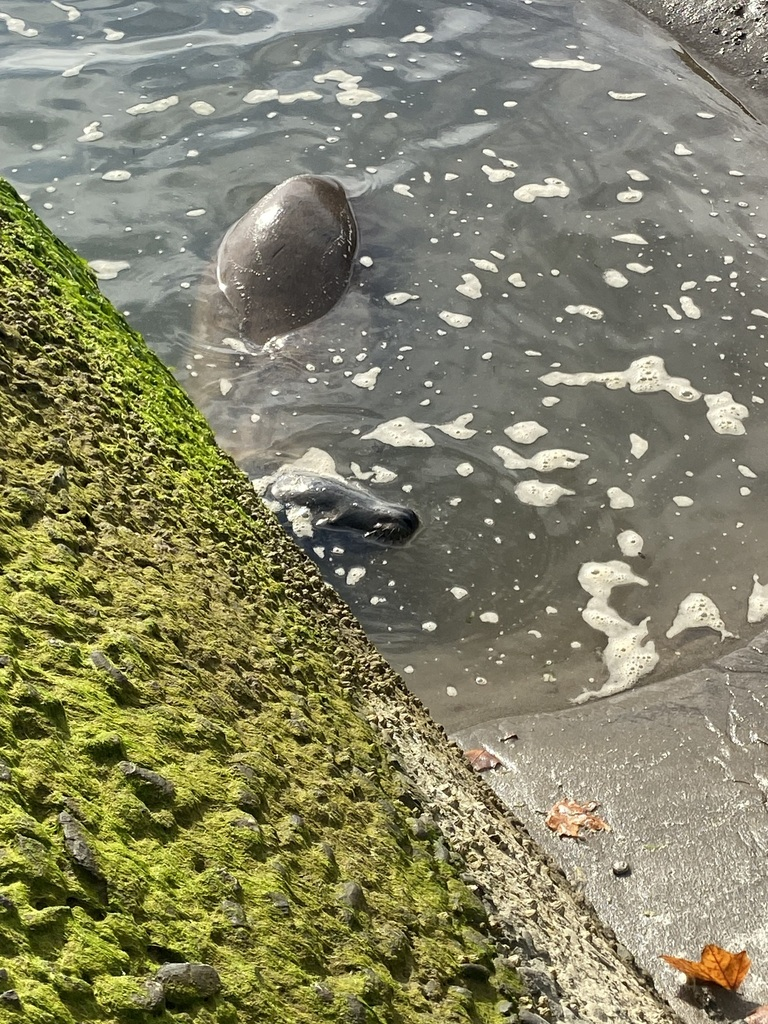


Generating new CV output from retaken image...

New CV output:
{
  "cv_species_top2": [
    {
      "common_name": "Seal",
      "genus": "Phocidae",
      "species": "",
      "probability": 95
    },
    {
      "common_name": "Harbor Seal",
      "genus": "Phoca",
      "species": "vitulina",
      "probability": 90
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "",
    "gaps_and_limits": "Only the head and part of the back are visible; the rest of the body is submerged.",
    "maximum_confidence_query": "Is the animal moving?"
  }
}

Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_species": "Harbor Seal",
  "llm_species_confidence": 0.88,
  "confidence_evidence_summary": "High CV probability for Harbor Seal, but only part of the animal is visible. User answers are inconclusive for species.",
  "cv_user_agreement_status": "partial_agre

Your answer:  uniform



Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_species": "Harbor Seal",
  "llm_species_confidence": 0.88,
  "confidence_evidence_summary": "CV strongly identifies a Harbor Seal; user description of uniform fur is not a strong contradiction.",
  "cv_user_agreement_status": "partial_agreement",
  "suggested_followup_question": "Does the fur have any spots or blotches?",
  "injury_summary": "No visible wounds or distress reported by CV or user.",
  "safety_guidance": "Observe from a safe distance and do not approach the animal."
}
Finish reason: FinishReason.STOP

LLM assessment output:
Animal group: None
Likely species: Harbor Seal
Updated confidence: 0.88
CV-user agreement: partial_agreement
Evidence summary: CV strongly identifies a Harbor Seal; user description of uniform fur is not a strong contradiction.
Injury summary: No visible wounds or distress reported by CV or user.
Guidance: Observe from a safe distance and do not approach the

Your answer:  no uniform brown



Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_species": "Phoca vitulina",
  "llm_species_confidence": 0.40,
  "confidence_evidence_summary": "CV suggests Harbor Seal, but user reports uniform fur, which contradicts typical spotted patterns.",
  "cv_user_agreement_status": "conflict",
  "suggested_followup_question": "Can you confirm if the fur has any distinct spots or rings, even faint ones, when dry?",
  "injury_summary": "No visible signs of injury or distress reported by CV or user.",
  "safety_guidance": "Maintain a safe distance from the animal."
}
Finish reason: FinishReason.STOP

LLM assessment output:
Animal group: None
Likely species: Phoca vitulina
Updated confidence: 0.4
CV-user agreement: conflict
Evidence summary: CV suggests Harbor Seal, but user reports uniform fur, which contradicts typical spotted patterns.
Injury summary: No visible signs of injury or distress reported by CV or user.
Guidance: Maintain a safe distance

In [ ]:
final_llm_output, followup_history = run_chatbox(
    model=llm_model,
    incident_package=incident_package,
    max_followups=5
)

print("\nFinal LLM output:")
print(json.dumps(final_llm_output, indent=2))

print("\nFollow-up history:")
print(json.dumps(followup_history, indent=2))

## Save To Incident Database (Handoff To Agent 2)

This step appends the finished conversation as one row to `Coordination_agent2/agent1_incident_database.csv`, which Agent 2 and the demo app read.

The column contract lives in `Coordination_agent2/agent1_incident_schema.json`. The save function checks the CSV header against it and refuses to write if they differ.

**Temporary storage notes**
- The CSV is a prototype store only. It will be replaced by a real database (SQLite locally, then Firestore or Cloud SQL for the deployed app) using the same column names.
- No locking: do not run two intake sessions that save at the same time.
- Append-only: each run of the save cell adds a new row. Set `SAVE_TO_DATABASE = False` while testing to avoid duplicate rows.
- On Cloud Run the file resets on every deploy, so rows written there are not kept.

**Injury flags:** the assessment prompt outputs the 10 injury and distress flags Agent 2 uses for triage (`llm_injury_present`, `llm_wound_present`, `llm_entanglement_present`, and so on). They are saved directly from the final assessment. `reported_color`, `reported_bleeding` and `cv_top3_*` stay empty because V8 does not collect them; the raw answers are kept in `incident_package_json`.

In [ ]:
import csv
import uuid
from datetime import datetime
from pathlib import Path

# TEMPORARY STORAGE: prototype CSV store. See the notes above and in the schema file.
DB_PATH = Path("../Coordination_agent2/agent1_incident_database.csv")
SCHEMA_PATH = Path("../Coordination_agent2/agent1_incident_schema.json")
VERIFIED_THRESHOLD = 0.90  # same threshold as decide_next_action

INCIDENT_SCHEMA = json.loads(SCHEMA_PATH.read_text(encoding="utf-8"))
DB_COLUMNS = [col["name"] for col in INCIDENT_SCHEMA["columns"]]


def _new_id(prefix):
    return f"{prefix}_{uuid.uuid4().hex[:8]}"


def _to_unit_confidence(value):
    """CV returns 0 to 100; the database stores 0 to 1."""
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return round(value / 100, 4) if value > 1 else round(value, 4)


def build_incident_row(incident_package, final_llm_output, followup_history):
    cv = incident_package.get("cv_output", {}) or {}
    loc = incident_package.get("location_output", {}) or {}
    answers = incident_package.get("user_fixed_answers", {}) or {}
    top = cv.get("cv_species_top2", []) or []
    features = cv.get("cv_observed_features", {}) or {}
    history = followup_history or []

    confidence = final_llm_output.get("llm_species_confidence")
    try:
        verified = float(confidence) >= VERIFIED_THRESHOLD
    except (TypeError, ValueError):
        verified = False

    def top_field(i, key):
        return top[i].get(key) if len(top) > i else None

    row = {
        "incident_id": _new_id("INC"),
        "photo_id": _new_id("PHOTO"),
        "animal_id": _new_id("ANIMAL"),
        "report_timestamp": datetime.now().isoformat(timespec="seconds"),
        "latitude": loc.get("latitude"),
        "longitude": loc.get("longitude"),
        "place_name": loc.get("place_name"),
        "location_source": loc.get("location_source"),
        "cv_top1_species": top_field(0, "common_name"),
        "cv_top1_confidence": _to_unit_confidence(top_field(0, "probability")),
        "cv_top2_species": top_field(1, "common_name"),
        "cv_top2_confidence": _to_unit_confidence(top_field(1, "probability")),
        "cv_possible_wound": features.get("possible_wound"),
        "cv_visible_blood": features.get("visible_blood"),
        "reported_size": answers.get("reported_size"),
        "reported_mobility": answers.get("reported_mobility"),
        "reported_visible_wound": answers.get("reported_visible_wound"),
        "llm_likely_species": final_llm_output.get("llm_likely_species"),
        "llm_species_confidence": confidence,
        "species_verification_status": "verified" if verified else "unverified",
        "llm_needs_followup": not verified,
        "llm_followup_type": history[-1].get("type") if history else None,
        "llm_followup_reason": None if verified else final_llm_output.get("confidence_evidence_summary"),
        "llm_followup_question": None if verified else final_llm_output.get("suggested_followup_question"),
        "new_photo_requested": any(h.get("type") == "request_new_photo" for h in history),
        "llm_injury_present": final_llm_output.get("llm_injury_present"),
        "llm_injury_confidence": final_llm_output.get("llm_injury_confidence"),
        "llm_wound_present": final_llm_output.get("llm_wound_present"),
        "llm_bleeding_present": final_llm_output.get("llm_bleeding_present"),
        "llm_entanglement_present": final_llm_output.get("llm_entanglement_present"),
        "llm_swelling_present": final_llm_output.get("llm_swelling_present"),
        "llm_abnormal_posture_present": final_llm_output.get("llm_abnormal_posture_present"),
        "llm_respiratory_distress_present": final_llm_output.get("llm_respiratory_distress_present"),
        "llm_unresponsive_present": final_llm_output.get("llm_unresponsive_present"),
        "llm_mobility_concern": final_llm_output.get("llm_mobility_concern"),
        "llm_injury_summary": final_llm_output.get("injury_summary"),
        "guidance_message": final_llm_output.get("safety_guidance"),
        "followup_count": len(history),
        "followup_history_json": json.dumps(history, ensure_ascii=False),
        "incident_package_json": json.dumps(incident_package, ensure_ascii=False, default=str),
        "final_llm_output_json": json.dumps(final_llm_output, ensure_ascii=False, default=str),
    }
    # Columns with no V8 source yet (see schema "not_collected") stay empty.
    return {col: ("" if row.get(col) is None else row.get(col)) for col in DB_COLUMNS}


def save_incident_row(row, db_path=DB_PATH):
    """Append one row. Refuses to write if the CSV header does not match the schema."""
    db_path = Path(db_path)
    if db_path.exists() and db_path.stat().st_size > 0:
        with open(db_path, newline="", encoding="utf-8") as f:
            header = next(csv.reader(f))
        if header != DB_COLUMNS:
            raise ValueError(
                f"{db_path} header does not match {SCHEMA_PATH.name} "
                f"(schema v{INCIDENT_SCHEMA['version']}). Not saving."
            )
        write_header = False
    else:
        write_header = True
    with open(db_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=DB_COLUMNS)
        if write_header:
            writer.writeheader()
        writer.writerow(row)
    return row["incident_id"]

In [ ]:
SAVE_TO_DATABASE = True  # set to False while testing to avoid duplicate rows

incident_row = build_incident_row(incident_package, final_llm_output, followup_history)
print("Row preview:")
print(json.dumps({k: incident_row[k] for k in [
    "incident_id", "place_name", "cv_top1_species", "cv_top1_confidence",
    "llm_likely_species", "llm_species_confidence", "species_verification_status",
    "followup_count", "new_photo_requested",
]}, indent=2))

if SAVE_TO_DATABASE:
    saved_id = save_incident_row(incident_row)
    print(f"\nSaved {saved_id} to {DB_PATH}")
else:
    print("\nSAVE_TO_DATABASE is False. Nothing written.")